# 📊 Global AI Job Market & Salary Trends 2025

## Problem Statement:

### Why are we doing this project?

 **Analyze the global AI job market to understand hiring trends, salary patterns, experience requirements, company characteristics, and remote work adoption.**

## Objectives:

**- Analyze AI job market trends.**

**- Identify high-paying AI roles.**

**- Study salary variation across experience levels.**

**- Compare salaries across countries and industries.**

**- Analyze company size impact.**

**- Study remote work trends.**

## Questions to be Answered

**1. Which AI roles are most common?**

**2. Which roles offer the highest salaries?**

**3. Does experience affect salary?**

**4. Which countries hire the most AI professionals?**

**5. Which countries offer the highest salaries?**

**6. Does company size affect salary?**

**7. How common is remote work?**

**8. Which industries hire AI talent?**

**9. Which education level is most requested?**

**10. Are there salary outliers?** 

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [2]:
df=pd.read_csv(r"C:\Users\91801\Downloads\ai_job_dataset.csv")

## Dataset Overview:

### Why analyse this?

- **Understanding datatypes helps identity numerical and categorical variables.**

In [4]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,18-10-2024,07-11-2024,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,20-11-2024,11-01-2025,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,18-03-2025,07-04-2025,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,23-12-2024,24-02-2025,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,15-04-2025,23-06-2025,1989,6.6,Advanced Robotics


### Observation

* The dataset contains information about AI jobs, salaries, companies, industries, experience levels, and employment details.

* Both categorical and numerical variables are available for analysis.
                                                        
* The dataset appears suitable for exploring AI job market trends and salary patterns.

## Why analyse this?

- **The dataset size helps us understand whether enough records are available for meaningful analysis.**

In [5]:
df.shape

(15000, 19)

### Observation

* The dataset contains 15,000 records and 19 columns.

* The dataset size is adequate for identifying patterns and trends in the AI job market.

## Dataset Information

- **Understanding Dataset Structure and Data Types**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

### Observation

* The dataset contains both numerical and categorical features.

* Numerical columns can be used for statistical and correlation analysis.
    
* Categorical columns can be used for grouping and trend analysis.


## Data Cleaning

### Missing Values

- **It effect data quality and must be checked before analysis.**


In [7]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

### Observation

* No missing values were detected in the dataset.

* The dataset is complete and ready for analysis without additional imputation.

* Data quality appears to be high.

**Duplicate Values**

In [8]:
df.duplicated().sum()

0

### Observation

* No duplicate records were detected in the dataset based on the available columns.


**Remove Unwanted Columns:**

In [9]:
df.drop( ['job_id', 'application_deadline'], axis=1,
          inplace=True)

In [10]:
df.columns

Index(['job_title', 'salary_usd', 'salary_currency', 'experience_level',
       'employment_type', 'company_location', 'company_size',
       'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'job_description_length', 'benefits_score', 'company_name'],
      dtype='object')

### Observation

* The columns 'job_id' and 'application_deadline' were removed because they do not contribute to salary or job market analysis.

* Removing unnecessary columns simplifies the dataset and improves readability.

## Statistical Summary

**Numerical :**

In [11]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115340.448800,49.483333,6.253200,1503.314733,7.504273
std,60261.708046,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70177.500000,0.000000,2.000000,1003.750000,6.200000
50%,99678.000000,50.000000,5.000000,1512.000000,7.500000
75%,146383.000000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


### Observation:

* The average salary is $115,349, with a wide salary range across job roles.
* Most positions require 2–10 years of experience, with an average of 6.25 years.
* Companies provide relatively strong benefits, with an average score of 7.5/10.
* The dataset contains 15,000 records, making it suitable for reliable analysis.

**Categorical summary:**

In [12]:
df.describe(include='object')

,job_title,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,required_skills,education_required,industry,posting_date,company_name
count,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,21,3,4,4,20,3,20,13663,4,15,486,16
top,Machine Learning Researcher,USD,MI,FT,Germany,S,Sweden,"Python, TensorFlow, PyTorch",Bachelor,Retail,05-07-2024,TechCorp Inc
freq,808,11957,3781,3812,814,5007,790,17,3789,1063,51,980


### Observation:

*Machine learning is the most common job role.*


## Unique Values:

- **Unique counts helps understand dataset diversity.**

In [13]:
df['experience_level'].nunique()

4

**Observation**

* **Experience Levels:** The dataset contains 4 categories representing different career stages.
    
* **Categories:** Entry-Level (EN), Mid-Level (MI), Senior-Level (SE), and Executive-Level (EX).
    
* **Importance:** This feature will help analyze how salary varies with professional experience.

In [14]:
df['company_size'].nunique()

3

 **Observation**

* **Company Sizes:** The dataset contains 3 company size categories.

* **Categories:** Small (S), Medium (M), and Large (L).

* **Importance:** This feature will help compare salary trends across organizations of different sizes.

In [15]:
df['employment_type'].nunique()

4

**Observation**

* **Employment Types:** The dataset includes multiple work arrangements.

* **Categories:** Full-Time, Part-Time, Contract, and Freelance positions.

* **Importance:** This feature helps understand workforce distribution and employment patterns in the AI job market.

In [16]:
df['salary_currency'].nunique()

3

### Observation 

* The dataset contains multiple unique salary currencies.

* This indicates that the data comes from different countries or regions.

## Outlier Analysis:

**1. Are there any salary outliers?**

**Detecting Outliers:**

In [17]:
Q1 = df['salary_usd'].quantile(0.25)
Q3 = df['salary_usd'].quantile(0.75)
Q1,Q3


(70177.5, 146383.0)

In [18]:
IQR = Q3 - Q1
IQR

76205.5

In [19]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower)
print(upper)

outliers = df[ (df['salary_usd'] < lower) |(df['salary_usd'] > upper)]

print("Number of Outliers:", len(outliers))
print(outliers.shape)

-44130.75
260691.25
Number of Outliers: 484
(484, 17)


### Boxplot for Outliers

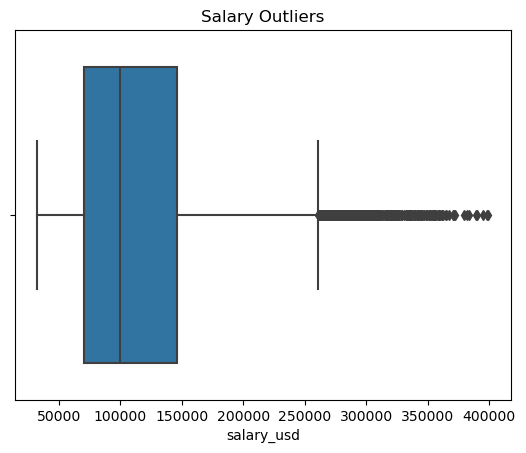

In [20]:
sns.boxplot(x=df['salary_usd'])
plt.title("Salary Outliers")
plt.show()

### Observation

* A total of 483 salary outliers were identified using the IQR method.
    
* These outliers likely represent highly specialized or executive-level AI positions.
    
* Since salary datasets naturally contain executive and specialized positions, removing outliers could distort real market conditions.

## Pivot Table Analysis

**Salary by Experience :**

In [21]:
pivot_exp = pd.pivot_table(
    df,
    values='salary_usd',
    index='experience_level',
    aggfunc='mean')
pivot_exp

,salary_usd
experience_level,
EN,63128.781124
EX,187723.647340
MI,87955.471833
SE,122173.861497


### Observation

* **Highest Salary Group:** Executive-level (EX) professionals earn the highest average salary at approximately **$187,724**.

* **Senior-Level Employees:** Senior professionals (SE) earn an average salary of approximately **$122,188**, significantly higher than mid-level and entry-level employees.

* **Mid-Level Employees:** Mid-level professionals (MI) earn approximately **$87,955** on average.

* **Entry-Level Employees:** Entry-level employees (EN) receive the lowest average salary at approximately **$63,133**.

* **Clear Progression:** Average salary consistently increases with experience level, indicating a strong relationship between expertise and compensation.

**Salary by Company Size :**

In [22]:
pivot_company = pd.pivot_table(
    df,
    values='salary_usd',
    index='company_size',
    aggfunc='mean')
pivot_company

,salary_usd
company_size,
L,130296.892557
M,113600.237037
S,102146.930098


### Observation

* **Highest Average Salary:** Large companies (L) offer the highest average salary at approximately $130,322.
  
* **Medium Companies:** Medium-sized companies (M) provide an average salary of around $113,600.

* **Small Companies:** Small companies (S) offer the lowest average salary at approximately $102,147.
 
* **Salary Trend:** Average salary increases with company size, indicating that larger organizations generally provide better compensation packages.
  
* **Key Insight:** Company size appears to have a positive impact on employee salaries in the AI job market.

**Salary by Industry :**

In [23]:
pivot_industry = pd.pivot_table(
    df,
    values='salary_usd',
    index='industry',
    aggfunc='mean')
pivot_industry.sort_values(
    by='salary_usd',
    ascending=False).head(10)

,salary_usd
industry,
Consulting,117602.142157
Manufacturing,116162.888773
Media,116127.730144
Education,116026.803347
Real Estate,115919.095333
Technology,115705.468843
Government,115694.321643
Finance,115323.398374
Telecommunications,115291.411234


### Observation

* **Highest Paying Industry:** Consulting offers the highest average salary at approximately **$117,602**, making it the top-paying industry in the dataset.

* **Strong Competition:** Manufacturing and Media industries closely follow with average salaries above **$116,000**.

* **Technology Sector:** Despite being a major AI employer, the Technology industry ranks below Consulting, Manufacturing, Media, Education, and Real Estate in terms of average salary.
    
* **Salary Consistency:** The average salaries across the top 10 industries are relatively close, ranging from approximately **$115,188 to $117,602**.


**Salary by Country :**

In [24]:
pivot_country = pd.pivot_table(
    df,
    values='salary_usd',
    index='company_location',
    aggfunc='mean')
pivot_country.sort_values(
    by='salary_usd',
    ascending=False).head(10)

,salary_usd
company_location,
Switzerland,170639.085791
Denmark,165652.249357
Norway,159490.533981
United States,146833.045580
United Kingdom,128720.186557
Singapore,128004.035340
Netherlands,126750.451436
Sweden,123559.753989
Germany,121810.143735


### Observation

* **Highest Paying Country:** Switzerland offers the highest average salary at approximately **$170,639**, making it the most lucrative location for AI professionals in the dataset.
                                                                                                                                                
* **Top Salary Markets:** Denmark and Norway follow closely with average salaries exceeding **$159,000**, indicating strong compensation in Northern European countries.

* **United States Position:** The United States ranks fourth with an average salary of approximately **$146,833**, remaining one of the highest-paying AI job markets globally.
    
* **Global Salary Variation:** Significant differences exist in average salaries across countries, highlighting the impact of geographic location on compensation.

* **Key Insight:** Countries with advanced economies and strong technology ecosystems tend to offer higher salaries for AI-related roles.

## Visual Analysis

**1.Which AI job roles are most common?**

In [25]:
df['job_title'].value_counts().head(10)

job_title
Machine Learning Researcher    808
AI Software Engineer           784
Autonomous Systems Engineer    777
Machine Learning Engineer      772
AI Architect                   771
Head of AI                     765
NLP Engineer                   762
Robotics Engineer              759
Data Analyst                   759
AI Research Scientist          756
Name: count, dtype: int64

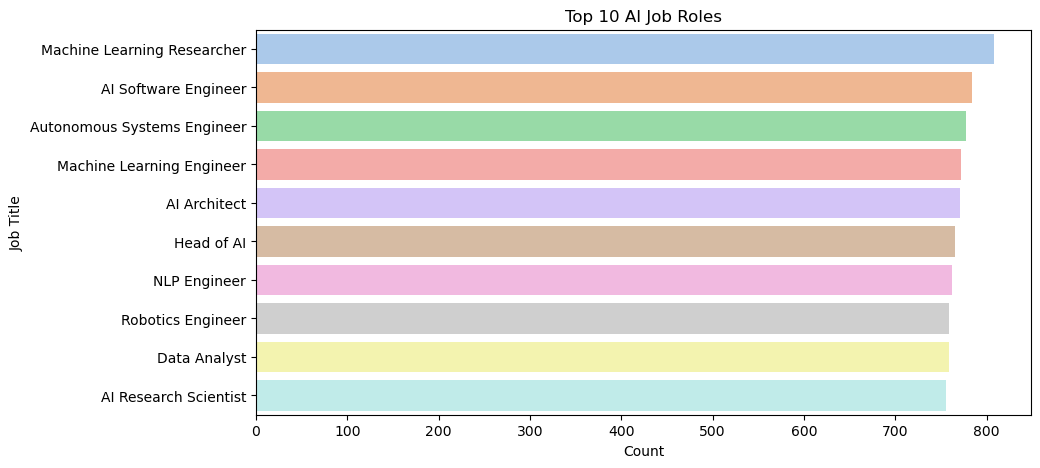

In [28]:
top=df['job_title'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top.values,y=top.index,palette='pastel')
plt.title('Top 10 AI Job Roles')
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()


### Observation

* **Highest Demand:** Machine Learning Researcher is the most frequently listed role with 808 job posting
 s.
* **Strong Demand for Engineering Roles:** AI Software Engineer, Autonomous Systems Engineer, and Machine Learning Engineer are among the most sought-after positio
 ns.
* **Leadership Demand:** AI Architect and Head of AI positions also appear in the top 10, indicating demand for experienced AI lead
 ers.
* **Market Trend:** Organizations are actively investing in research, development, automation, and AI infrastruc
  onals.

**2. Which roles offer the highest salaries?**

In [26]:
df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).head(10)


job_title
AI Specialist                120497.559835
Machine Learning Engineer    118827.919689
Head of AI                   118542.968627
AI Research Scientist        117897.925926
AI Architect                 117436.513619
Robotics Engineer            116470.793149
Principal Data Scientist     116305.219346
Research Scientist           116066.502695
Data Engineer                115970.720961
Data Scientist               115819.008333
Name: salary_usd, dtype: float64

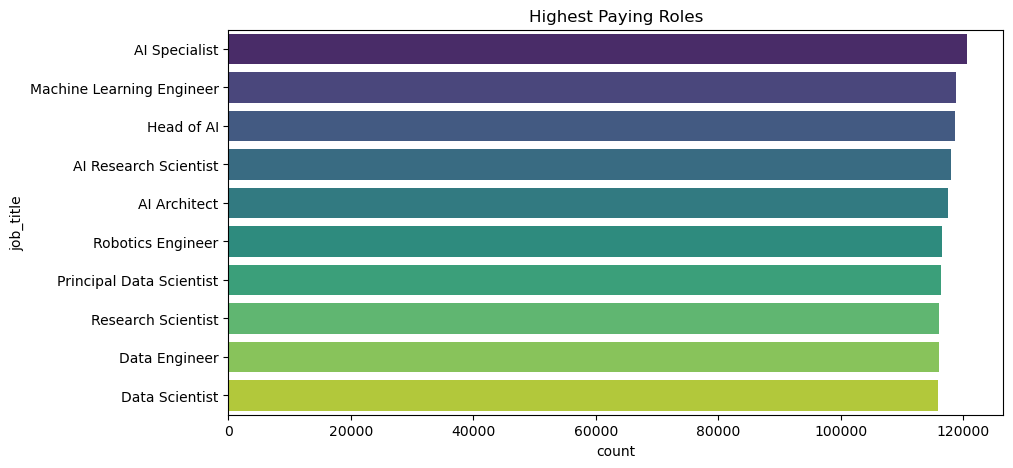

In [27]:
x=df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=x.values,y=x.index,palette='viridis')
plt.title('Highest Paying Roles')
plt.xlabel("count")
plt.ylabel("job_title")
plt.show()

### Observation
* AI Specialist has the highest average salary (~$120.6K).

* Machine Learning Engineer and Head of AI also offer very high salaries (~$118K+).

* AI Research Scientist and AI Architect follow closely.

* Robotics Engineer and Data roles also have strong salary ranges (~$116K+).
  ential.

**3. Does experience affect salary?**

In [28]:
df.groupby('experience_level')['salary_usd'].mean()

experience_level
EN     63128.781124
EX    187723.647340
MI     87955.471833
SE    122173.861497
Name: salary_usd, dtype: float64

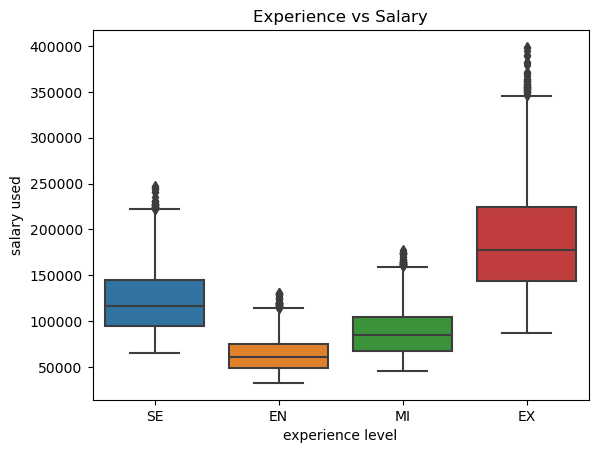

In [3]:
sns.boxplot(df,x='experience_level',y='salary_usd')
plt.title("Experience vs Salary")
plt.xlabel("experience level")
plt.ylabel("salary used")
plt.show()

### Observation** Executive-level (EX) professionals receive the highest slary.**r.
** Senior level (SE) also earns significantly high (~$122.1)**K
** Mid level (MI) has moderate salary (~$87.9)**K
** Entry level (EN) has the lowest salary (~$63.1)**K
** Salary clearly increases with experience lev in ai jo market**.

**4.Which countries hire the most AI professionals?**

In [30]:
df['company_location'].value_counts().head(10)

company_location
Germany      814
Denmark      778
France       769
Canada       769
Austria      765
Singapore    764
China        763
India        754
Sweden       752
Israel       751
Name: count, dtype: int64

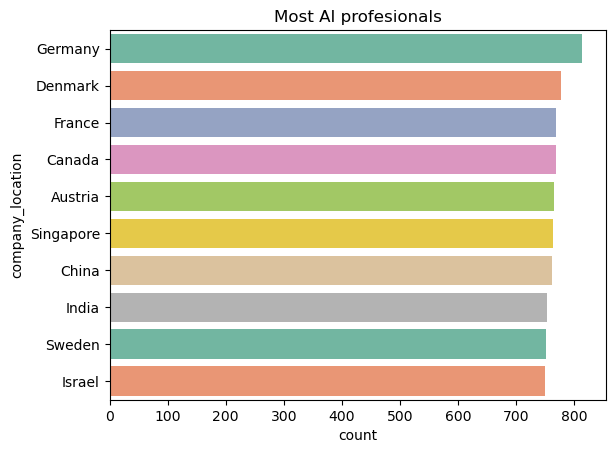

In [4]:
top=df['company_location'].value_counts().head(10)
sns.barplot(x=top.values,y=top.index,palette='Set2')
plt.title("Most AI profesionals") 
plt.xlabel("count")
plt.show()

### Observation

* **Highest Representation:** Germany has the highest number of AI professionals with 814 job posting
  s.
* **Strong European Presence:** Germany, Denmark, France, Austria, and Sweden all appear among the top hiring locatio
  ns.
* **Global Participation:** Canada, Singapore, China, India, and Israel also contribute significantly to AI employm
  ent.
* **Balanced Distribution:** The differences between countries are relatively small, indicating widespread global demand for AI tal  untry.

**5. Which Countries offer the highest salaries?**

In [32]:
df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False).head(10)


company_location
Switzerland       170639.085791
Denmark           165652.249357
Norway            159490.533981
United States     146833.045580
United Kingdom    128720.186557
Singapore         128004.035340
Netherlands       126750.451436
Sweden            123559.753989
Germany           121810.143735
Australia         118064.372951
Name: salary_usd, dtype: float64

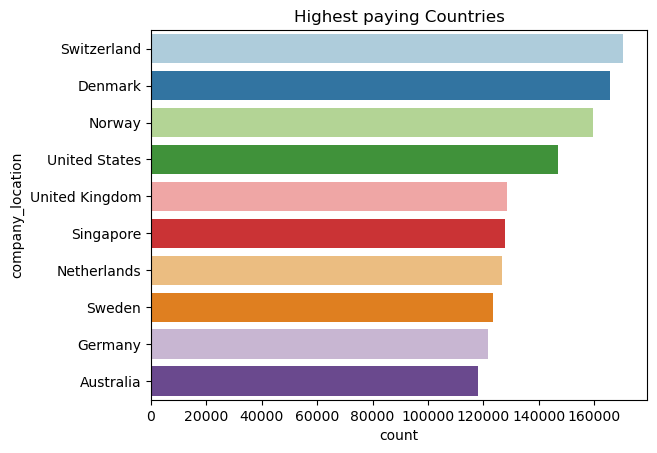

In [31]:
x=df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=x.values,y=x.index,palette='Paired')
plt.title("Highest paying Countries")
plt.xlabel('count')
plt.show()

### Observations: 

* **Switzerland has the highest average salary (~$170.6K).**

* **Denmark and Norway follow closely with very high average salaries.**

* **The United States ranks 4th with a strong average salary (~$146.8K).**

* **Most top-paying locations are European countries.**

* **United Kingdom, Singapore, and Netherlands also show competitive salary levels.**

* **Australia is the lowest among the top 10 but still has a high average salary (~$118.2K).**

**6.Does company size affect Salary?**

In [33]:
df.groupby('company_size')['salary_usd'].mean()

company_size
L    130296.892557
M    113600.237037
S    102146.930098
Name: salary_usd, dtype: float64

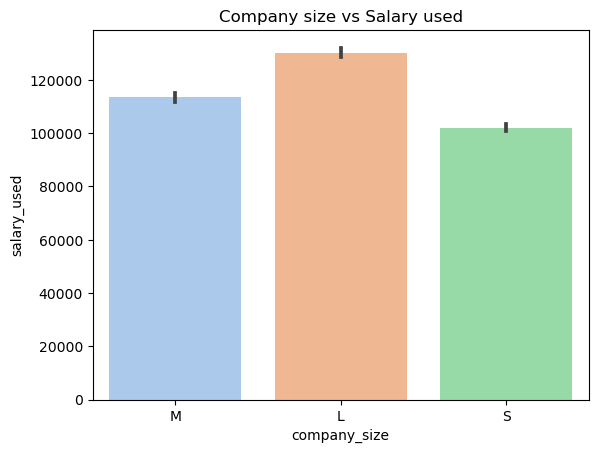

In [33]:
sns.barplot(df,x='company_size',y='salary_usd',palette='pastel')
plt.title("Company size vs Salary used")
plt.xlabel('company_size')
plt.ylabel('salary_used')
plt.show()

### Observations: 

* **Large companies (L) have the highest average salary (~$130.3K).**
  
* **Medium companies (M) offer a lower average salary (~$113.6K) compared to large companies.**
  
* **Small companies (S) have the lowest average salary (~$102.1K).**
  
* **There is a clear trend: salary increases with company size.**
  
* **Larger organizations tend to pay significantly more than smaller ones.**

**7.How common is remote work?**

In [34]:
df['remote_ratio'].value_counts()

remote_ratio
0      5075
50     5005
100    4920
Name: count, dtype: int64

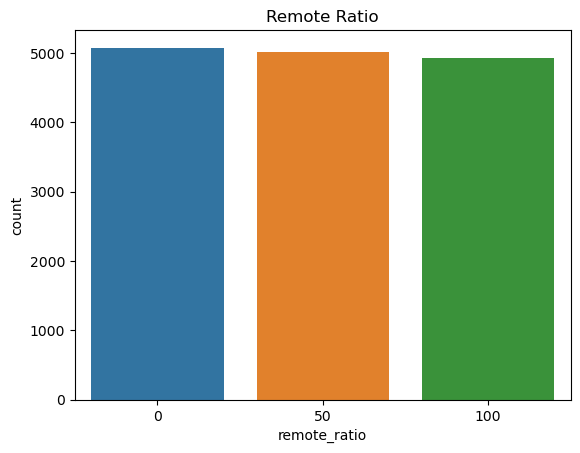

In [35]:
sns.countplot(df,x='remote_ratio')
plt.title("Remote Ratio")
plt.xlabel('remote_ratio')
plt.ylabel('count')
plt.show()

### Observation

* Jobs are almost equally distributed across remote levels (0%, 50%, 100%).

* Each category has around 5,000 records, showing balanced dataset.


**8. Does remote work affect Salary ?**

In [67]:
df.groupby('remote_ratio')['salary_usd'].mean()

remote_ratio
0      114140.231133
50     115776.806793
100    116160.545935
Name: salary_usd, dtype: float64

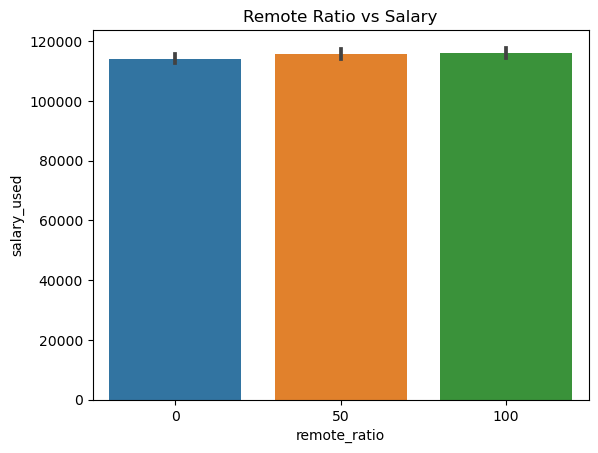

In [21]:
sns.barplot(df,x='remote_ratio',y='salary_usd')
plt.title("Remote Ratio vs Salary")
plt.xlabel("remote_ratio")
plt.ylabel("salary_used")
plt.show()

### Observations 

* Fully remote jobs (100%) have the highest average salary (~$116.1K).
                                                          
* Hybrid jobs (50%) follow closely (~$115.7K).
                                                          
* On-site jobs (0%) have the lowest average salary (~$114.1K).
                                                          
* Salary difference across remote types is very small.

**9. Employment Type Distribution**

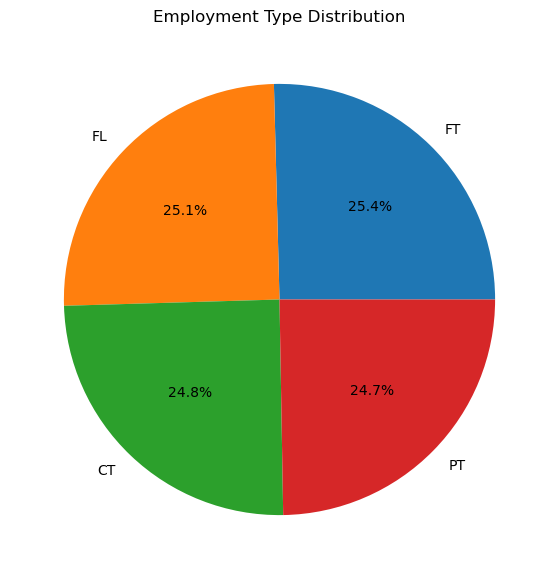

In [69]:
employment = df['employment_type'].value_counts()
plt.figure(figsize=(7,7))
plt.pie( employment,labels=employment.index,autopct='%1.1f%%')
plt.title("Employment Type Distribution")
plt.show()

### Observation

* Employment types are almost evenly distributed across the dataset.
    
* Full-Time (FT) positions have the highest share (25.4%).
    
* Part-Time (PT), Contract (CT), and Freelance (FL) roles each contribute about 25% of jobs.
    
* No single employment type dominates the AI job market, indicating diverse work opportunities.

**10. Which Education level is most requested?**

In [70]:
df['education_required'].value_counts()

education_required
Bachelor     3789
Associate    3785
Master       3748
PhD          3678
Name: count, dtype: int64

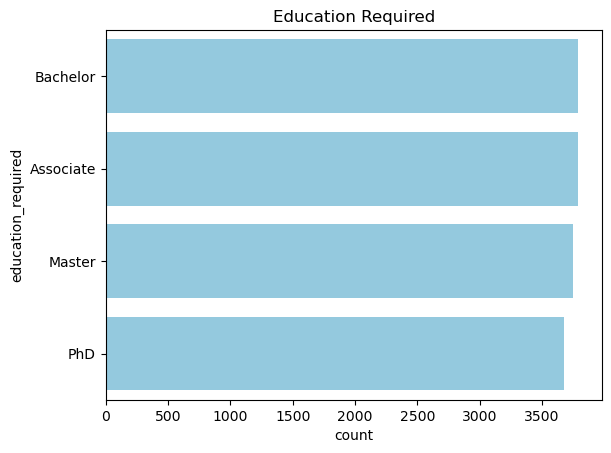

In [36]:
sns.countplot(df,y='education_required',order=df['education_required'].value_counts().index,color='skyblue')
plt.title("Education Required")
plt.xlabel("count")
plt.show()

### Observation

* Bachelor, Associate, Master, and PhD are almost equally represented.

* Bachelor degree has slightly highest count.

* PhD has the lowest count, but difference is minimal.

* Dataset shows no strong bias toward a single education level.

**11. Which Industries hire AI talent?**

In [72]:
df['industry'].value_counts(5)

industry
Retail                0.070867
Media                 0.069667
Automotive            0.068000
Consulting            0.068000
Technology            0.067400
Real Estate           0.067133
Government            0.066533
Healthcare            0.066467
Telecommunications    0.066467
Transportation        0.066467
Finance               0.065600
Energy                0.065067
Gaming                0.064467
Manufacturing         0.064133
Education             0.063733
Name: proportion, dtype: float64

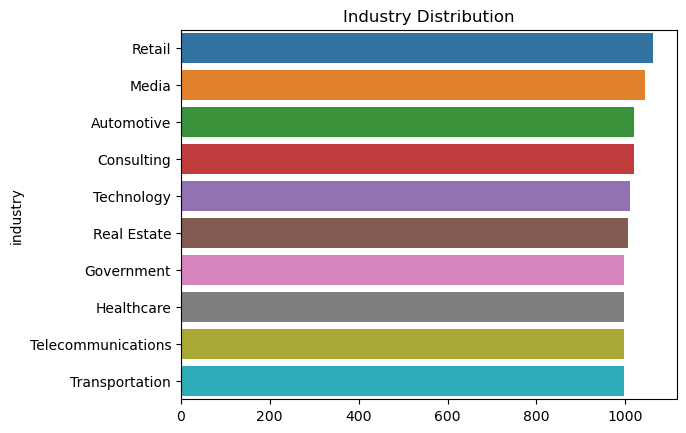

In [11]:
top=df['industry'].value_counts().head(10)
sns.barplot(x=top.values,y=top.index)
plt.title("Industry Distribution")
plt.show()


### Observations

* Retail, Media, Automotive, Consulting, and Technology are most common industries.

* All industries have nearly equal share (~6–7%).
                                          
* No single industry dominates the dataset.

**12. Which industries offer highest salaries?**

In [74]:
df.groupby('industry')['salary_usd'].mean().sort_values(ascending=False).head(10)


industry
Consulting            117602.142157
Manufacturing         116162.888773
Media                 116127.730144
Education             116026.803347
Real Estate           115919.095333
Technology            115831.823937
Government            115694.321643
Finance               115323.398374
Telecommunications    115291.411234
Energy                115188.436475
Name: salary_usd, dtype: float64

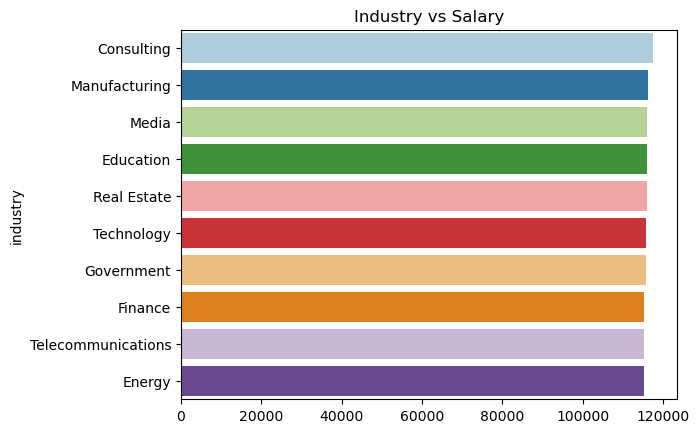

In [35]:
x=df.groupby('industry')['salary_usd'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=x.values,y=x.index,palette='Paired')
plt.title("Industry vs Salary")
plt.show()

### Observations

* Consulting has the highest average salary (~$117.6K).

* Manufacturing and Media also offer high salaries (~$116K).

* Education, Technology, Government, Finance, and Energy are in a similar mid-range (~$115K).

* Salary differences across industries are small but noticeable.

**13. Salary Currency Distribution**

In [76]:
df['salary_currency'].value_counts()

salary_currency
USD    11957
EUR     2314
GBP      729
Name: count, dtype: int64

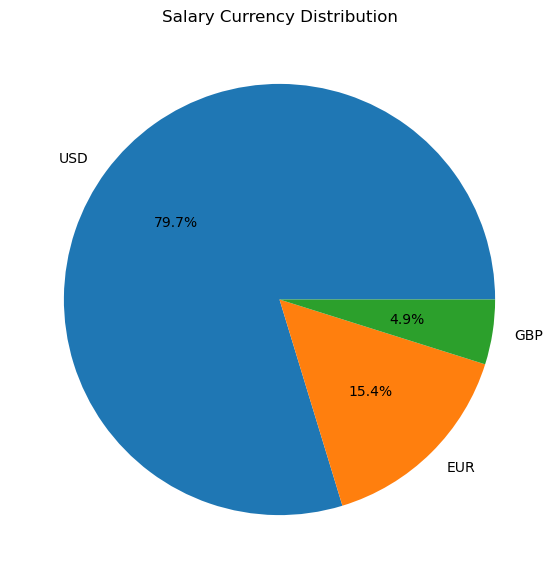

In [77]:
currency = df['salary_currency'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    currency,
    labels=currency.index,
    autopct='%1.1f%%')
plt.title("Salary Currency Distribution")
plt.show()

### Observation

* USD dominates the dataset, accounting for nearly 80% of salary records.
    
* EUR and GBP represent a much smaller share, indicating that most salaries are reported in USD.

**14. Relationship between Years of Experience vs Salary :**

In [78]:
df[['years_experience','salary_usd']].corr()

,years_experience,salary_usd
years_experience,1.000000,0.737556
salary_usd,0.737556,1.000000


### Observation

* Strong positive correlation (0.737) between years of experience and salary.

* As experience increases, salary also increases significantly.
    
* Experience is one of the strongest predictors of salary in this dataset.

* This shows a clear career growth pattern with time.

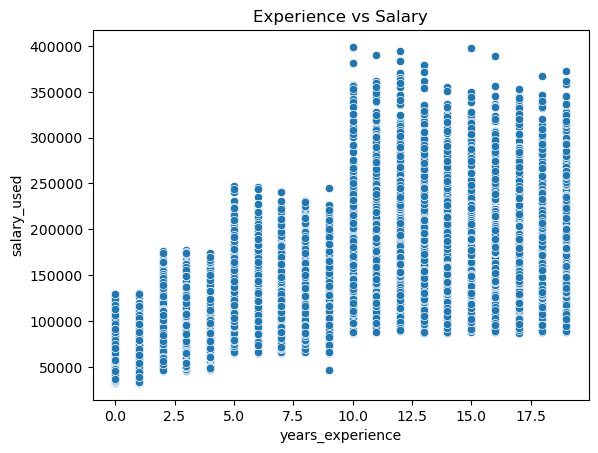

In [22]:
sns.scatterplot(df,x='years_experience',y='salary_usd')
plt.title("Experience vs Salary")
plt.xlabel("years_experience")
plt.ylabel("salary_used")
plt.show()

### Observation

* Salary generally increases with years of experience, showing a positive relationship between experience and compensation.

* Professionals with 10+ years of experience tend to earn the highest salaries in the dataset.

**15. Benifits score Distribution?**

In [80]:
df['benefits_score'].describe()

count    15000.000000
mean         7.504273
std          1.450870
min          5.000000
25%          6.200000
50%          7.500000
75%          8.800000
max         10.000000
Name: benefits_score, dtype: float64

C:\Users\91801\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


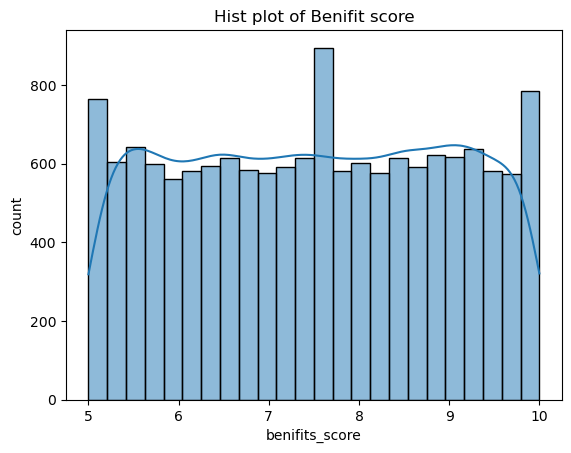

In [23]:
sns.histplot(df['benefits_score'],kde=True)
plt.title("Hist plot of Benifit score")
plt.xlabel("benifits_score")
plt.ylabel('count')
plt.show()

### Obseervation

* Average benefits score is ~7.5 out of 10.

* Most employees fall between 6.2 and 8.8 (middle 50%).

* Minimum score is 5, maximum is 10.

* Benefits are generally good and fairly well distributed.There is no extreme imbalance occur.

**16. Top Hiring Companies?**

In [82]:
df['company_name'].value_counts().head(10)

company_name
TechCorp Inc                  980
Cognitive Computing           972
AI Innovations                964
Digital Transformation LLC    961
Future Systems                960
Quantum Computing Inc         960
Cloud AI Solutions            951
Predictive Systems            947
Smart Analytics               927
Advanced Robotics             925
Name: count, dtype: int64

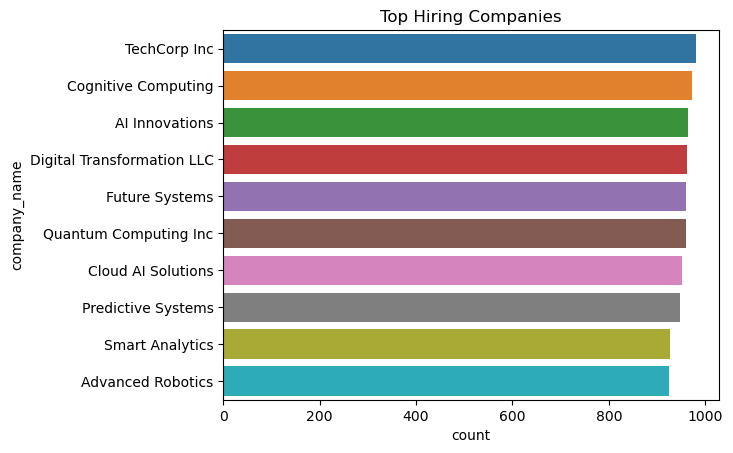

In [24]:
top=df['company_name'].value_counts().head(10)
sns.barplot(x=top.values,y=top.index)
plt.title("Top Hiring Companies")
plt.xlabel("count")
plt.ylabel("company_name")
plt.show()

### Observations

* TechCorp Inc has the highest number of employees (980).

* Cognitive Computing and AI Innovations follow closely.
    
* Digital Transformation LLC, Future Systems, and Quantum Computing Inc also have high representation.
    
* Top companies are mostly AI, cloud, and tech-focused firms.

**17. Job description length analysis?**

In [84]:
df['job_description_length'].describe()

count    15000.000000
mean      1503.314733
std        576.127083
min        500.000000
25%       1003.750000
50%       1512.000000
75%       2000.000000
max       2499.000000
Name: job_description_length, dtype: float64

C:\Users\91801\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


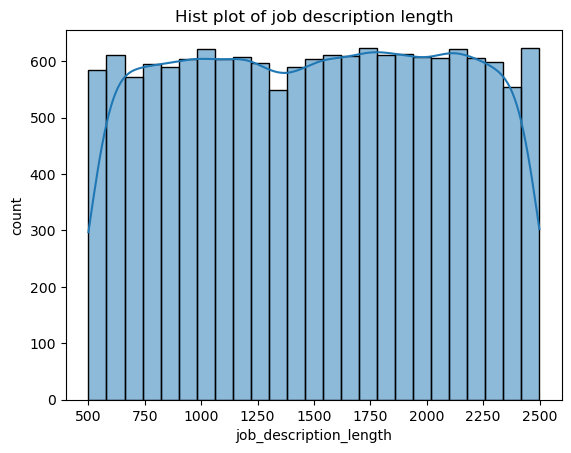

In [25]:
sns.histplot(df['job_description_length'],kde=True)
plt.title("Hist plot of job description length")
plt.ylabel("count")
plt.show()

### Observations

* Average job description length is ~1503 characters.

* Minimum length is 500 and maximum is 2499 characters.

* Most descriptions fall between ~1000 and 2000 characters.

## Correlation Analysis :

In [40]:
num=df.select_dtypes(include='number')
num.corr()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
salary_usd,1.000000,0.013725,0.737477,-0.009059,0.000995
remote_ratio,0.013725,1.000000,0.015321,0.004475,0.003139
years_experience,0.737477,0.015321,1.000000,-0.007526,-0.007275
job_description_length,-0.009059,0.004475,-0.007526,1.000000,0.006744
benefits_score,0.000995,0.003139,-0.007275,0.006744,1.000000


### Observations

* Salary has strongest relationship with years of experience (0.737).

* Remote ratio has almost no impact on salary.

* Job description length has negligible correlation with salary.

* Benefits score also shows almost no relationship with salary.

* Most factors except experience have very weak influence on salary.

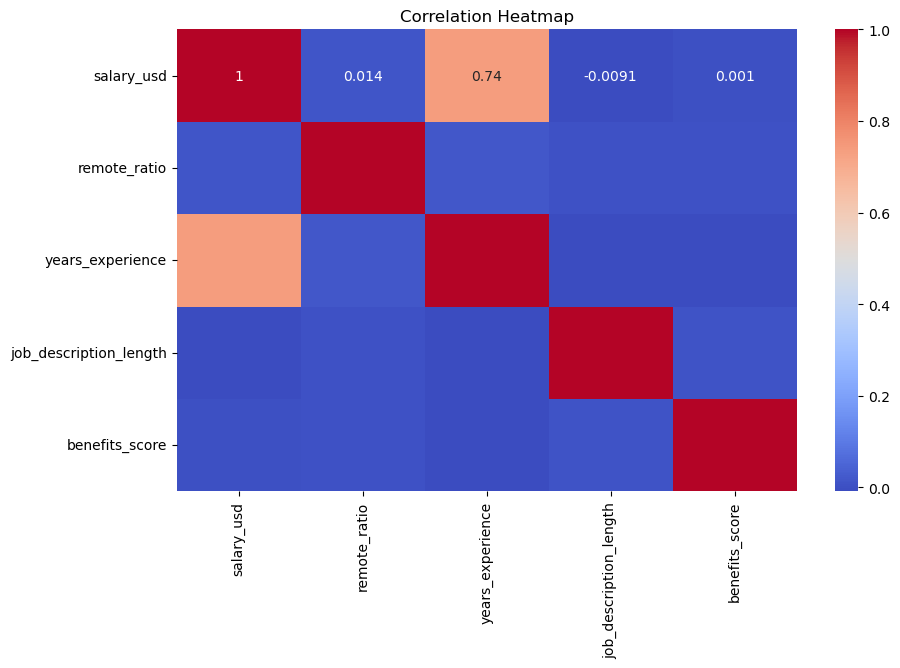

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(num.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observation

* Years of experience has a strong positive correlation with salary (0.74), indicating that more experienced professionals generally earn higher salaries.
* Remote ratio, job description length, and benefits score show very weak correlations with salary, suggesting they have minimal direct impact on compensation.
* Overall, experience is the most important numerical factor influencing salary in the dataset.

### Observations:

* Discuss relationships among salary, experience, benifits score and other numerical features.

### Key Insights

* **AI Engineer and Machine Learning Engineer are among the most demanded roles.**

* **Salary growth primarily follows experience progression.**

* **Company size has a noticeable effect on compensation.**

* **Experience level has a strong positive impact on salary.**

* **Large organizations generally provide better salary packages.**

* **Hiring demand is concentrated in a few major countries.**

* **Salary levels vary considerably across geographic regions.**

* **Industry choice influences earning potential.**

* **Remote work has become a common employment model.**

* **Full-time positions dominate the AI job market.**

* **Salary outliers represent highly specialized or senior roles.**

* **Benefits scores vary across organizations, indicating differences in employee offerings.**

* **AI continues to be a rapidly growing field with strong global demand.**

### Business Recommendations:

• **Professionals should focus on gaining experience to maximize earning potential.**

• **Job seekers should target industries and countries that offer higher salaries.**

• **Organizations can use salary trends to remain competitive in attracting AI talent.**

• **Upskilling in AI and machine learning remains valuable due to strong market demand.**

## Conclusion

**This analysis shows that experience, job role, company size, and location are key factors affecting salaries in the AI job market. Higher experience levels and larger organizations tend to offer better compensation. The findings highlight the growing global demand for AI professionals and the strong career opportunities available in this field.**
